# Introduccion a Machine Learning
- Introduccion desde el punto de vista del analisis de datos: Generar el mejor modelo posblie para aplicar modelos ML
- Analisis univariado y bivariado
- Desagregacion de modelos en training y tets

# Orden tipico de un modelo de Machine Learning
- Siempre validar si sea un aprendizaje supervisado o no supervisado
- Supervisado: analisis que se aplica a un set de datos que buscan la respuesta a una pregunta utilizanfo valores que ya fueron etiquetados: bueno/malo, 1/0, un rango de numeros, etc. Ejemplo: un modelo de regresion
- No Supervisado: analisis que se aplica a un set de datos que NO fueron etiquetados previamente. Ejemplo: El clustering de clientes

## Parte 1 - Preparacion
- Hacer EDA
- Analisis Univariado
- Analisis Bivariado - Correlacion
- Field Engineering
- Definir % de training y testing
- Definir los modelos que se van preliminarmente a ejecutar para entender la data
- Split de la data

### Exploratory Data Analysis (EDA)
- Base de cualquier modelo de ML
- Se va a explorar la informacion y prepararla para que el cientifico de datos aplique los modelos necesarios

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../../../Archivos-Analisis/files-practrica-m41/marketing_campaign.csv', sep=';')
df.sample(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
1932,1458,1982,Master,Married,21059.0,1,0,2014-01-07,40,8,...,6,0,0,0,0,0,0,3,11,0
1012,1710,1978,Graduation,Single,30168.0,1,0,2013-03-07,51,154,...,9,0,0,0,0,0,0,3,11,0
1777,164,1977,PhD,Married,28973.0,0,0,2012-10-13,59,206,...,8,0,0,0,0,0,0,3,11,0
955,10031,1976,PhD,Married,16927.0,1,1,2013-02-10,50,20,...,8,0,0,0,0,0,0,3,11,0
1226,4058,1955,PhD,Single,61284.0,0,0,2013-10-12,76,618,...,6,0,1,0,0,0,0,3,11,0
1349,1745,1962,PhD,Divorced,85696.0,0,0,2013-05-03,88,714,...,1,0,0,0,0,0,0,3,11,1
1373,5675,1960,PhD,Divorced,50611.0,0,1,2012-10-04,98,459,...,6,0,1,0,0,0,0,3,11,0
2176,1544,1967,Master,Divorced,81380.0,0,0,2012-12-22,51,741,...,2,0,0,0,0,0,0,3,11,0
284,8962,1975,Master,Married,44319.0,1,1,2014-04-17,18,26,...,5,0,0,0,0,0,0,3,11,0
1217,8876,1963,PhD,Together,33629.0,1,1,2012-08-08,49,132,...,9,0,0,0,0,0,0,3,11,0


In [3]:
# Obtnemos los tipos de datos del df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
# Obtenemos los principales estadísticos del df
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [5]:
df.shape

(2240, 29)

In [4]:
# Validar cuantas celdas en total son nulas
missing_values_count = df.isnull().sum()
missing_values_count

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [5]:
# Buscamos los valores nulos
df.loc[df['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,2013-11-15,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,2013-11-05,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,2014-01-01,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,2013-06-17,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,2012-09-14,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,2012-11-19,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,2014-05-27,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,2013-11-23,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,2013-07-11,23,352,...,6,0,0,0,0,0,0,3,11,0


In [6]:
# Calculamos el % total de datos que no existen
# Cuantos datos totales tenemos, y cuantos faltan
total_cells = np.prod(df.shape)
total_missing = missing_values_count.sum()

# Calculamos el porcentaje
percent_missing = (total_missing/total_cells) * 100
print(f'Porcentaje de datos faltantes: {percent_missing:.2f}%')

Porcentaje de datos faltantes: 0.04%


In [7]:
# Numero de valores no unicos
# Para ver la estructura interna de cada columna que tan variada es
df.nunique().sort_values()

Z_Revenue                 1
Z_CostContact             1
Response                  2
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp2              2
Complain                  2
AcceptedCmp1              2
AcceptedCmp5              2
Kidhome                   3
Teenhome                  3
Education                 5
Marital_Status            8
NumCatalogPurchases      14
NumStorePurchases        14
NumDealsPurchases        15
NumWebPurchases          15
NumWebVisitsMonth        16
Year_Birth               59
Recency                 100
MntFruits               158
MntSweetProducts        177
MntFishProducts         182
MntGoldProds            213
MntMeatProducts         558
Dt_Customer             663
MntWines                776
Income                 1974
ID                     2240
dtype: int64

Insights
- Las columnas Z_CostContract y Z_Renueve tienen los mismos valores para todos los percentiles. Deberia validarse si hace sentido incluirla o no
- Ademas se valida con el comando nunique() que tienen un solo valor por lo que deben de ser eliminadas
- Se debe imputar un valor a las celdas income del dataset que tienen Nulos como valor. Se deberia preguntar al negocio si esta variable es crucial, ya que tal vez podria eliminarse
- Se asume, para el caso, que se puede imputar el promedio total de Income del dataset

### Analisis Univariado

In [8]:
# Muestra los tipos de datos
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

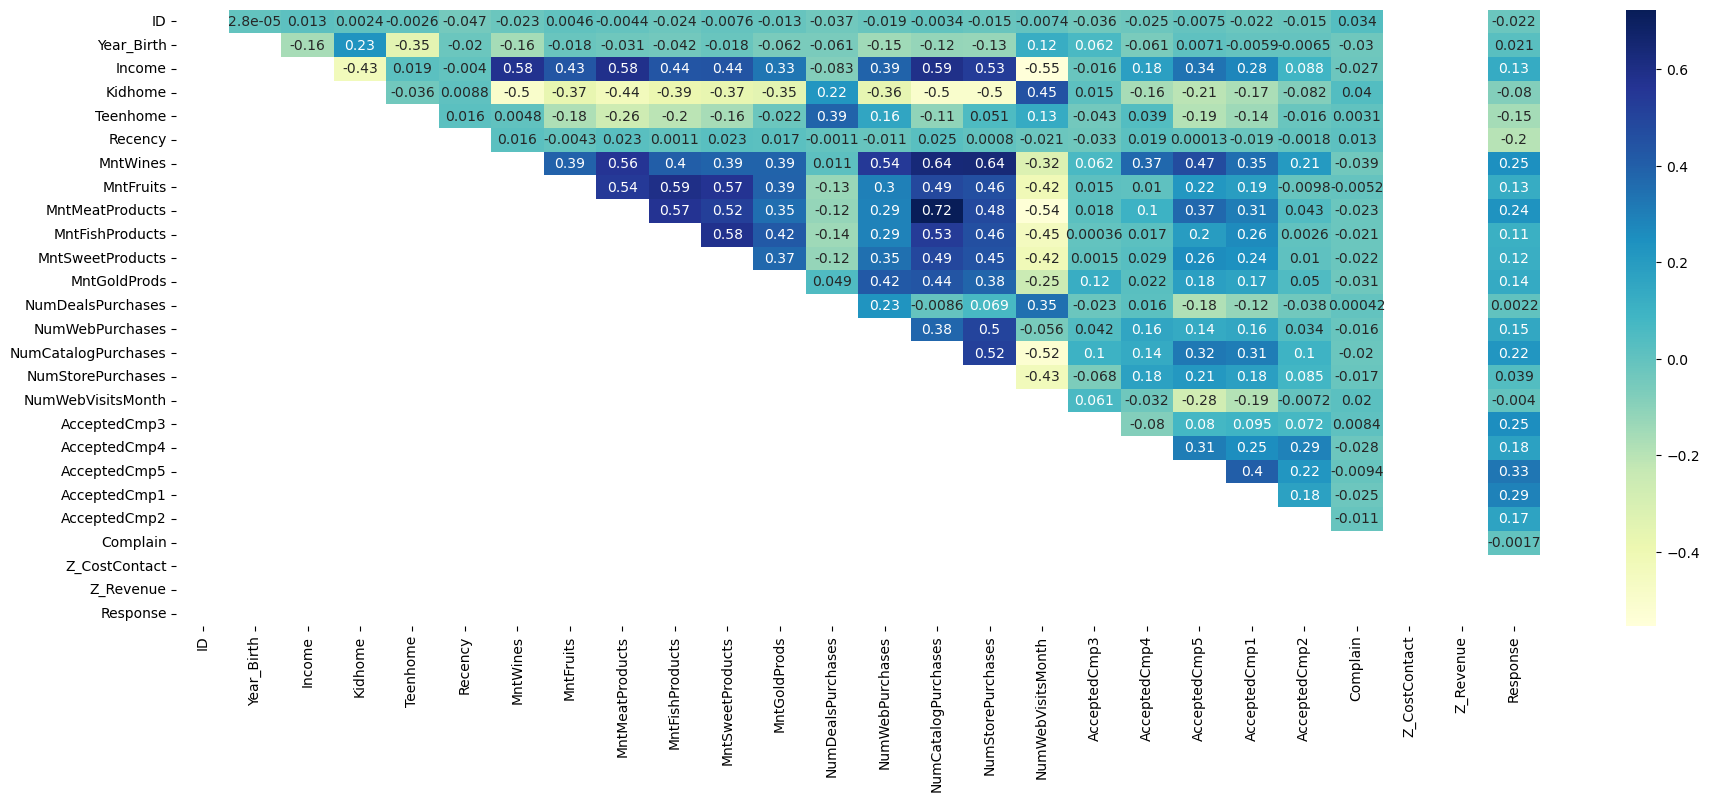

In [9]:
# Grafico de correlacion
plt.figure(figsize=(22, 8))
corr_df = corr = df.select_dtypes(include=[np.number]).corr(method='pearson')
df_lt = corr_df.mask(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt, cmap='YlGnBu', annot=True)

Insights
- Los campos MntWines, MnFruits, Mnt en general tienen un sesgo importnte hacia la derecha. Para los modelos de ML eso no ayuda al proceso, por lo que debemos generar campos adicionales con su logaritmo natural, que permiten una figura menos sesgada
- Asi mismo, la clase de respuesta final (Response), se ve desbalanceada (imbalaced class)

---

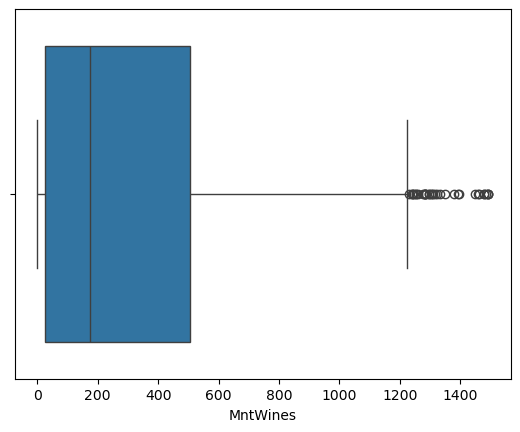

In [10]:
# Se busca outliners con graficos box-plot
ax = sns.boxplot(x= df['MntWines'])
# En este caso particularmente no se ven valores tan lejanos de los limites

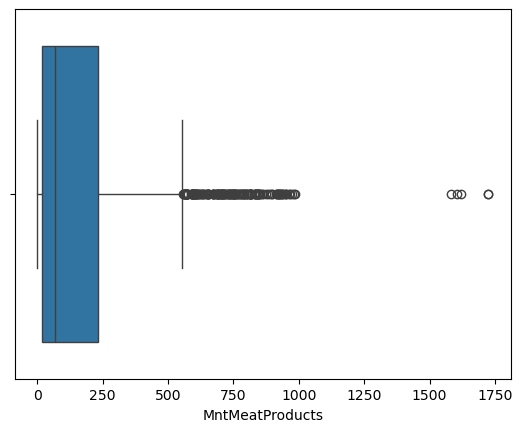

In [11]:
# En cambio para el grafico de meat products se puede ver con mucha mas claridad la presencia de outliners
# lo que cpnfirma el alto sesgo de la vaiable
ax = sns.boxplot(x=df['MntMeatProducts'])

Insights de la Correlacion
- Tambien sse hace una analisis de correlacion para validar variables que tengan datos no compatibles
- Para encontrar variables que tengan relaciones muy altas unas con otras (>0.9), lo que las hace sospechosas de ser casuales, es decir, que una sea causa de la otra
- No se encuentra nunguna variable que deba ser eliminada por alta correlacion
- La variable con la correlacion mas alta es Num CatalogPurchases cmbinada con MntMeatProducts (0.7)

### Analisis Bivariado

In [12]:
# Se muestran las diferentes valores de las variables segun el Estado Civil
# una de las variables interesantes a analizar es el estado civil = alone y analizar por ejemplo MntMeatProducts o MntFruits
df.groupby(['Marital_Status']).apply(lambda x: x.select_dtypes(include=[np.number]).mean()).round(2).T

C:\Users\RyanHz\AppData\Local\Temp\ipykernel_18624\2231545585.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['Marital_Status']).apply(lambda x: x.select_dtypes(include=[np.number]).mean()).round(2).T


Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
ID,6051.5,2728.33,5427.06,5633.15,5489.24,5644.67,5969.56,5812.5
Year_Birth,1975.0,1973.00,1966.28,1969.58,1971.49,1967.75,1958.56,1973.0
Income,72365.5,43789.00,52834.23,51724.98,50995.35,53245.53,56481.55,48432.0
Kidhome,0.0,1.00,0.41,0.46,0.46,0.45,0.23,0.0
Teenhome,0.0,0.67,0.59,0.51,0.41,0.53,0.64,1.0
Recency,53.0,30.33,49.49,48.28,49.51,50.11,49.14,3.0
MntWines,355.5,184.67,324.84,299.48,288.33,306.83,369.27,322.0
MntFruits,84.5,4.00,27.43,25.73,26.84,25.35,33.09,3.0
MntMeatProducts,312.5,26.33,150.21,160.68,182.11,168.10,189.29,50.0
MntFishProducts,205.5,7.67,35.04,35.38,38.22,38.99,51.39,4.0


In [13]:
# Cuando se analiza la variable Response es muy interesante ver los diferentes comportamientos de las variables
# Aqui se ve la mediana de cada variable, ahora agrupamos por su respuesta a la propuesta de la institucion
df.groupby(['Response']).apply(lambda x: x.select_dtypes(include=[np.number]).median()).round(2).T

C:\Users\RyanHz\AppData\Local\Temp\ipykernel_18624\1636426480.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['Response']).apply(lambda x: x.select_dtypes(include=[np.number]).median()).round(2).T


Response,0,1
ID,5528.0,5133.0
Year_Birth,1970.0,1971.0
Income,50150.0,64090.0
Kidhome,0.0,0.0
Teenhome,1.0,0.0
Recency,52.0,30.0
MntWines,152.0,448.0
MntFruits,7.0,21.0
MntMeatProducts,56.0,174.5
MntFishProducts,11.0,25.0


---

### Field Engineering
- Se refiere a los distintos pasos que se deben tomar parta dejar mas limpio y preparado el dataset para el modelo
- Eliminar las columnas con un solo valor: Z_Costcontact y Z_Revenue
- Eliminar las lineas con nulos
- Cambiar el tipo de dato de la columna Education y Marital_Status

#### Eliminacion de columnas

In [14]:
# Las siguientes columnas no sirven para el modelo
df.drop('Z_CostContact', axis=1, inplace=True)
df.drop('Z_Revenue', axis=1, inplace=True)

In [15]:
df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
488,3436,1969,Graduation,Married,14045.0,1,0,2014-01-26,24,11,...,0,3,7,0,0,0,0,0,0,0
1364,10507,1977,2n Cycle,Divorced,59601.0,0,1,2013-07-25,14,691,...,2,7,8,0,1,0,0,0,0,0
256,309,1961,PhD,Together,63342.0,0,1,2012-10-16,48,918,...,3,5,6,0,1,0,0,0,0,0
1756,3798,1968,Graduation,Married,41120.0,1,1,2013-11-06,80,24,...,1,3,6,0,0,0,0,0,0,0
704,968,1968,Master,Divorced,41335.0,1,0,2013-12-26,24,112,...,1,4,7,0,0,0,0,0,0,0


#### Validacion de nulos

In [16]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
dtype: int64

In [17]:
df.loc[df['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
10,1994,1983,Graduation,Married,NaN,1,0,2013-11-15,11,5,...,0,2,7,0,0,0,0,0,0,0
27,5255,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,...,0,0,1,0,0,0,0,0,0,0
43,7281,1959,PhD,Single,NaN,0,0,2013-11-05,80,81,...,3,4,2,0,0,0,0,0,0,0
48,7244,1951,Graduation,Single,NaN,2,1,2014-01-01,96,48,...,1,4,6,0,0,0,0,0,0,0
58,8557,1982,Graduation,Single,NaN,1,0,2013-06-17,57,11,...,0,3,6,0,0,0,0,0,0,0
71,10629,1973,2n Cycle,Married,NaN,1,0,2012-09-14,25,25,...,0,3,8,0,0,0,0,0,0,0
90,8996,1957,PhD,Married,NaN,2,1,2012-11-19,4,230,...,2,8,9,0,0,0,0,0,0,0
91,9235,1957,Graduation,Single,NaN,1,1,2014-05-27,45,7,...,0,2,7,0,0,0,0,0,0,0
92,5798,1973,Master,Together,NaN,0,0,2013-11-23,87,445,...,4,8,1,0,0,0,0,0,0,0
128,8268,1961,PhD,Married,NaN,0,1,2013-07-11,23,352,...,1,7,6,0,0,0,0,0,0,0


In [18]:
# A las filas con valores nulos, se les asignara la media
avg_mean = df['Income'].mean()

# Imputuamos el promedio a todos los registros definidos como NaN
df = df.replace(np.nan, avg_mean)

In [19]:
# Validamos el cambio
df.loc[df['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response


#### Cambio del tipo de adto de las columnas

In [20]:
# Cambiamos el tipo de dato a categoria, que hacen mas faciles las predicciones
# en los modelos de ML
df['Education'] = df['Education'].astype('category')
df['Marital_Status'] = df['Marital_Status'].astype('category')

In [21]:
df.dtypes

ID                        int64
Year_Birth                int64
Education              category
Marital_Status         category
Income                  float64
Kidhome                   int64
Teenhome                  int64
Dt_Customer              object
Recency                   int64
MntWines                  int64
MntFruits                 int64
MntMeatProducts           int64
MntFishProducts           int64
MntSweetProducts          int64
MntGoldProds              int64
NumDealsPurchases         int64
NumWebPurchases           int64
NumCatalogPurchases       int64
NumStorePurchases         int64
NumWebVisitsMonth         int64
AcceptedCmp3              int64
AcceptedCmp4              int64
AcceptedCmp5              int64
AcceptedCmp1              int64
AcceptedCmp2              int64
Complain                  int64
Response                  int64
dtype: object

---

### Preparacion Final antes del Split
- Eliminar columnas con alta correlacion
- Generar clases para imbalances internos
- Eliminar el ID (No aporta a la prediccion)

In [22]:
# Generamos una copia del df original
df_copy = df.copy()

In [23]:
# Eliminamos el ID
df_copy.drop('ID', axis=1, inplace=True)

In [24]:
# Eliminamos dt_customer
df_copy.drop('Dt_Customer',axis= 1, inplace=True)

In [25]:
# Generamos las variables trnafosmadas logarimicamente
# Para variables que tienen el sesgo alto
df_copy['MntWines-log'] = np.log(df_copy['MntWines'] + 1)
df_copy['MntFruits-log'] = np.log(df_copy['MntFruits'] + 1)
df_copy['MntMeatProducts-log'] = np.log(df_copy['MntMeatProducts'] + 1)
df_copy['MntFishProducts-log'] = np.log(df_copy['MntFishProducts'] + 1)
df_copy['MntSweetProducts-log'] = np.log(df_copy['MntSweetProducts'] + 1)
df_copy['NumDealsPurchases-log'] = np.log(df_copy['NumDealsPurchases'] + 1)
df_copy['NumWebPurchases-log'] = np.log(df_copy['NumWebPurchases'] + 1)
df_copy['NumCatalogPurchases-log'] = np.log(df_copy['NumCatalogPurchases'] + 1)

# Se usa el +1 para evitar errores de log(0) que nos daria division para cero

In [26]:
df_copy.sample(5)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,Complain,Response,MntWines-log,MntFruits-log,MntMeatProducts-log,MntFishProducts-log,MntSweetProducts-log,NumDealsPurchases-log,NumWebPurchases-log,NumCatalogPurchases-log
874,1978,Master,Together,61346.0,1,0,34,562,58,168,...,0,0,6.333280,4.077537,5.129899,3.784190,2.833213,0.693147,1.791759,2.079442
810,1981,Graduation,Married,26872.0,0,0,0,3,10,8,...,0,0,1.386294,2.397895,2.197225,1.386294,2.833213,0.693147,0.693147,0.693147
131,1958,Master,Alone,61331.0,1,1,42,534,5,47,...,0,0,6.282267,1.791759,3.871201,0.000000,1.791759,1.791759,2.484907,0.693147
124,1983,Graduation,Single,101970.0,0,0,69,722,27,102,...,0,1,6.583409,3.332205,4.634729,3.806662,4.290459,0.000000,1.945910,2.197225
451,1969,Graduation,Married,56796.0,0,1,24,656,38,161,...,0,0,6.487684,3.663562,5.087596,4.143135,3.871201,1.386294,2.197225,2.302585


Insights
- Ahora con los logs, tranformaciones y ademas cambiamos datos
- Se puede ver como las varaibles tipo log traen mucha mas informacion
- Muy importante definir si es que se van a dejar las variables en el dataset trabajado (df_copy) o eliminar

---

### Data Split
- Rompiendo el data set en 70 y 30
- Los modelos de ML generalmente se rompen en dos datasets, uno de entrenamiento del modelo (70) y uno de testing del modelo (30)
- Este generalmente es el paso final con el Cientifico de Datos

In [27]:
# Libreria de Split
from sklearn.model_selection import train_test_split

x = df_copy.drop('Response', axis=1) # El array x no va a contemplar la respuesta
y = df_copy['Response'] # Clase a predecir
# Se divide en X y Y en un ratio de 70:30

# Convertir categoricas en dummies
x = pd.get_dummies(x, drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=1)

In [28]:
x_train.head(5)

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
1747,1946,66835.0,0,0,21,620,26,195,34,17,...,False,True,False,False,False,True,False,False,False,False
115,1962,50785.0,1,1,27,64,1,21,0,1,...,True,False,False,False,False,False,True,False,False,False
1739,1971,42403.0,1,0,18,22,1,11,0,5,...,False,False,True,False,False,True,False,False,False,False
336,1968,75693.0,0,0,10,797,153,293,72,97,...,True,False,False,False,True,False,False,False,False,False
2031,1955,67225.0,0,1,4,315,35,322,46,7,...,True,False,False,False,False,True,False,False,False,False


---

## Parte 2 - Ejecucion
- Imputacion de Datos
- Balance de clases
- Ejecutar modelos
- Matriz de cinfunsion
- Validar precision e indicadores de modelo

---

# Machine Learning 2
- Conceptos basicos de datos de modeloado y masajeo basico de datos de preparacion
- Imputacion de Datos
- Balanceo de Clases
- Desagregacion de modelos en training y test
- Matriz de Confunsion
- Principales Scores de un modelo

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv('../../../Archivos-Analisis/files-practrica-m41/marketing_campaign.csv', sep=';')
df.sample(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2024,4837,1965,PhD,Married,71322.0,0,1,2013-02-16,57,753,...,4,0,0,0,0,0,0,3,11,0
597,7444,1969,Master,Married,42169.0,1,1,2013-10-19,20,19,...,8,0,0,0,0,0,0,3,11,0
1506,851,1972,Master,Married,57136.0,1,1,2013-07-09,48,306,...,6,0,0,0,0,0,0,3,11,0
948,6515,1977,Graduation,Together,39771.0,1,0,2013-12-06,92,6,...,4,0,0,0,0,0,0,3,11,0
1933,7007,1968,Master,Married,29543.0,2,0,2014-04-01,47,17,...,7,0,0,0,0,0,0,3,11,0
679,9596,1980,PhD,Single,65295.0,0,0,2013-12-23,19,365,...,2,0,0,0,0,0,0,3,11,0
1571,9916,1954,Graduation,Married,38998.0,1,1,2012-11-03,92,34,...,8,0,0,0,0,0,1,3,11,0
1152,10710,1979,Graduation,Married,7500.0,0,1,2012-08-29,61,5,...,8,0,0,0,0,0,0,3,11,0
32,5710,1970,Graduation,Together,40548.0,0,1,2012-10-10,31,110,...,5,0,1,0,0,0,0,3,11,0
137,9579,1959,PhD,Married,33762.0,2,1,2013-07-07,61,53,...,8,0,0,0,0,0,0,3,11,0


## Field Engineering Basico - Ejercicio Anterior

In [32]:
df.drop('Z_CostContact', axis=1, inplace=True)
df.drop('Z_Revenue', axis=1, inplace=True)
df.drop('ID', axis=1, inplace=True)

## Imputacion de datos

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   i

In [35]:
# Obtiene la moda de cada una de las columnas numericas
df.mode(axis='rows', numeric_only=True).T

,0
Year_Birth,1976.0
Income,7500.0
Kidhome,0.0
Teenhome,0.0
Recency,56.0
MntWines,2.0
MntFruits,0.0
MntMeatProducts,7.0
MntFishProducts,0.0
MntSweetProducts,0.0


In [ ]:
# Reemplazamos con el promedio general
avg_mean = df['Income'].mean()


# Imputa el promedio a todos los registros 
df.replace(np.nan, avg_mean, inplace=True)

---

In [37]:
# Se puede hacer luego un analisis bivariado grafico, donde se analicen por respuesta, los distintos estados civiles
ct = pd.crosstab(df['Marital_Status'], df['Response'], normalize=True)
ct

Response,0,1
Marital_Status,,
Absurd,0.000446,0.000446
Alone,0.000893,0.000446
Divorced,0.082143,0.021429
Married,0.341964,0.043750
Single,0.166964,0.047321
Together,0.232143,0.026786
Widow,0.025893,0.008482
YOLO,0.000446,0.000446


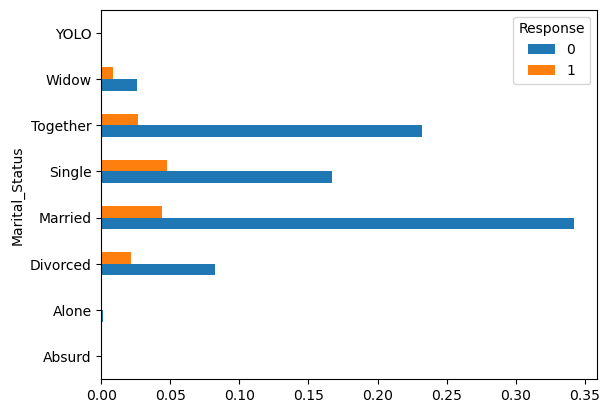

In [40]:
ct = pd.crosstab(df['Marital_Status'], df['Response'], normalize=True).plot.barh(stacked=False)

In [38]:
pd.crosstab(df['Marital_Status'], df['Response'], normalize='columns')

Response,0,1
Marital_Status,,
Absurd,0.000525,0.002994
Alone,0.001049,0.002994
Divorced,0.096537,0.143713
Married,0.401889,0.293413
Single,0.196222,0.317365
Together,0.272823,0.179641
Widow,0.030430,0.056886
YOLO,0.000525,0.002994


---

## Balance de Clases
- Se encuentran las variables categorias para ver su balance interno
- Si existen muy poco valores para algunoa categoria, se la puede merge con otra
- Generalmente, para que esten balanceados las clases, deben al menos un 5% de representacion

In [41]:
categ_columns = ['Marital_Status',  'Education', 'Response']
for column in categ_columns:
    print('\n' + column)
    print(df[column].value_counts())


Marital_Status
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Education
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Response
Response
0    1906
1     334
Name: count, dtype: int64


In [42]:
# asigna clases que tienen poca representacion a la categoria 'Other'
df['Marital_Status'].replace({'Widow': 'Other', 'Alone': 'Other', 'Absurd': 'Other', 'YOLO': 'Other'}, inplace=True)

In [44]:
categ_colums = ['Marital_Status']
for column in categ_colums:
    print('\n' + column)
    print(df[column].value_counts())


Marital_Status
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Other        84
Name: count, dtype: int64


In [45]:
# Se vewn los estados civiles nuevos, incluyendo Other
df.groupby(['Marital_Status']).apply(lambda x: x.select_dtypes(include=[np.number]).median()).round(2).T

C:\Users\RyanHz\AppData\Local\Temp\ipykernel_18624\307014976.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['Marital_Status']).apply(lambda x: x.select_dtypes(include=[np.number]).median()).round(2).T


Marital_Status,Divorced,Married,Other,Single,Together
Year_Birth,1968.0,1971.00,1958.0,1972.0,1969.0
Income,52683.0,52247.25,55453.5,49277.5,52137.0
Kidhome,0.0,0.00,0.0,0.0,0.0
Teenhome,1.0,0.00,1.0,0.0,1.0
Recency,51.0,48.00,48.0,51.0,51.0
MntWines,182.5,173.00,327.0,153.5,183.5
MntFruits,7.5,7.00,10.0,9.0,8.0
MntMeatProducts,71.5,64.00,83.0,65.0,68.0
MntFishProducts,10.0,12.00,21.5,12.0,12.0
MntSweetProducts,7.0,8.00,10.5,9.0,9.0


Insights
- En el Estado Civil, las clases Alone, Absurd y YOLO tiene nada mas 2 o 3 ocurrencias cada una
- Se podrian jugar y ser una categoria 'Otro', pero representacion nada mas el 0.02% (5 / 2240)
- La recomendacion aqui serie combinar Widow (77 registros + Alone, Absurd y YOLO = 82 registros = 3.6% del total)

---

## Preparacion Final antes del split 
- Eliminar columnas con alta correlacion
- Generar clases para imbalances internos
- Eliminar el ID (no va ser relevante en la prediccion)

In [46]:
df2 = df.copy()

In [47]:
df2.drop('Dt_Customer', axis=1, inplace=True)

In [48]:
# Muestra los valores unicos de Eduacion y Estado Civil
print(df['Education'].unique())
print(df['Marital_Status'].unique())

df['Education'] = df['Education'].astype('category')
df['Marital_Status'] = df['Marital_Status'].astype('category')

['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
['Single' 'Together' 'Married' 'Divorced' 'Other']


In [49]:
# Generar cariables transformadas logarimicamente
df2['MntWines-log'] = np.log(df2['MntWines'] + 1)
df2['MntFruits-log'] = np.log(df2['MntFruits'] + 1)
df2['MntMeatProducts-log'] = np.log(df2['MntMeatProducts'] + 1)
df2['MntFishProducts-log'] = np.log(df2['MntFishProducts'] + 1)
df2['MntSweetProducts-log'] = np.log(df2['MntSweetProducts'] + 1)
df2['NumDealsPurchases-log'] = np.log(df2['NumDealsPurchases'] + 1)
df2['NumWebPurchases-log'] = np.log(df2['NumWebPurchases'] + 1)
df2['NumCatalogPurchases-log'] = np.log(df2['NumCatalogPurchases'] + 1)

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df2['Income_scaled'] = StandardScaler().fit_transform(df2[['Income']])

## Data Split
- Rompiendo el data set en 70 / 30

In [51]:
# Libreria de Split
from sklearn.model_selection import train_test_split

x = df2.drop('Response', axis=1) # El array x no va a contemplar la respuesta
y = df2['Response'] # Clase a predecir
# Se divide en X y Y en un ratio de 70:30

# Convertir categoricas en dummies
x = pd.get_dummies(x, drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=1)

In [52]:
x_train.head(5)

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumCatalogPurchases-log,Income_scaled,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
1747,1946,66835.0,0,0,21,620,26,195,34,17,...,1.609438,0.582759,False,False,True,False,True,False,False,False
115,1962,50785.0,1,1,27,64,1,21,0,1,...,0.693147,-0.058415,False,True,False,False,False,False,True,False
1739,1971,42403.0,1,0,18,22,1,11,0,5,...,0.000000,-0.393263,False,False,False,True,True,False,False,False
336,1968,75693.0,0,0,10,797,153,293,72,97,...,1.609438,0.936623,False,True,False,False,False,False,False,False
2031,1955,67225.0,0,1,4,315,35,322,46,7,...,1.098612,0.598339,False,True,False,False,True,False,False,False


---

## Prueba simple con regresion logica
- Al ser las respuestas 0 y 1, se tiene que la regresion logistica es el modelo elegion
- Se usa la libreria 'LogisticRegression' para ejecutar la regresion
- Se debe tener en cuenta que el modelo hace fit con el set de Training (x_train, y_train)
- Y luego el modelo hace la prediccion con el modelo de Test
- Revision de tutoriales de Regresion logistica

In [ ]:
from sklearn import metrics
from sklearn.linear_model import LogisticRegression

# Adapta el modelo a los x_train y y_train
model = LogisticRegression(class_weight={0:0.15, 1:0.85}, solver='liblinear') # Modelo de regresion logistica
model.fit(x_train, y_train)

# Hace la prediccion en x_test y la guarda en y_pred
y_pred = model.predict(x_test)

In [54]:
# La prediccion no es mas que un conjunto de 0s y 1s que se aplican al mismo dataset
y_pred[0:100]

array([1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [55]:
# Construir un dataset con el calor original y la prediccion
z = x_test.copy()
z['Response real'] = y_test
z['Response prediccion'] = y_pred
z[['Response real', 'Response prediccion']].head(10)

,Response real,Response prediccion
779,0,1
389,0,0
510,0,1
1553,0,0
1172,0,1
1204,0,0
2057,0,0
1960,0,0
615,0,0
761,0,0


---

## Bonus

In [56]:
# Bonus
# Genera los coeficientes de la ecuacion
coef_df = pd.DataFrame(model.coef_)
coef_df.columns = x.columns

# Incluye el intercept
coef_df['intercept'] = model.intercept_
coef_df.T

,0
Year_Birth,-0.001862
Income,0.000011
Kidhome,0.325965
Teenhome,-0.900233
Recency,-0.027651
MntWines,0.001618
MntFruits,0.000812
MntMeatProducts,0.000062
MntFishProducts,-0.001470
MntSweetProducts,0.000215


---

## Matriz de Confusion
- Entender Falsos Positivos, Falsos Negativos
- Medidas de precision de modelos

Text(0.5, 1.0, 'Matriz de Confusion')

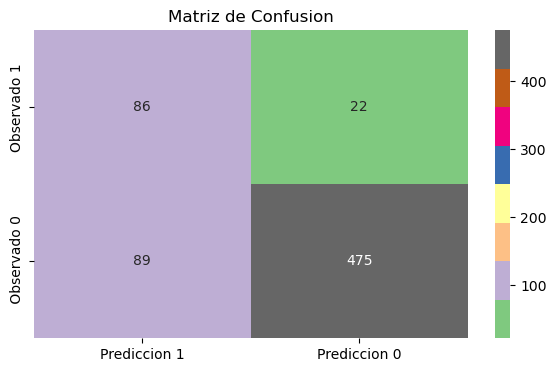

In [57]:
# Que no es mas que la comparacion de los valores observados y las predicciones, para que tan buena es la calidad del modelo
cm = metrics.confusion_matrix(y_test, y_pred, labels=[1,0])

df_cm = pd.DataFrame(cm, index = [i for i in ['Observado 1', ' Observado 0']],
                     columns = [i for i in ['Prediccion 1', 'Prediccion 0']])
plt.figure(figsize=(7,4))
sns.heatmap(df_cm, annot=True, cmap='Accent', fmt='d').set_title('Matriz de Confusion')

In [58]:
df_cm

,Prediccion 1,Prediccion 0
Observado 1,86,22
Observado 0,89,475


In [65]:
TP = df_cm.iloc[0][0]
FP = df_cm.iloc[0][1]
TN = df_cm.iloc[1][1]
FN = df_cm.iloc[1][0]

print(f'True Positives: {TP}')
print(f'False Positives: {FP}')
print(f'True Negatives: {TN}')
print(f'False Negatives: {FN}')

True Positives: 86
False Positives: 22
True Negatives: 475
False Negatives: 89


C:\Users\RyanHz\AppData\Local\Temp\ipykernel_18624\3121194666.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  TP = df_cm.iloc[0][0]
C:\Users\RyanHz\AppData\Local\Temp\ipykernel_18624\3121194666.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  FP = df_cm.iloc[0][1]
C:\Users\RyanHz\AppData\Local\Temp\ipykernel_18624\3121194666.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  TN = df_cm.iloc[1][1]
C:\Users\RyanHz\AppData\Loca

In [64]:
# Medidas del modelo
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix

y_pred = model.predict(x_test)
model_score = accuracy_score(y_test, y_pred)
recall_score = recall_score(y_test, y_pred)
precision_score = precision_score(y_test, y_pred)
f1_score = f1_score(y_test, y_pred)

print('Medidas del modelo:')
print('-------------------')
print(f'Accuracy: {model_score:.2f}')
print(f'Recall: {recall_score:.2f}')
print(f'Precision: {precision_score:.2f}')
print(f'F1 Score: {f1_score:.2f}')
print('Roc Auc Score:', roc_auc_score(y_test, y_pred))

Medidas del modelo:
-------------------
Accuracy: 0.83
Recall: 0.80
Precision: 0.49
F1 Score: 0.61
Roc Auc Score: 0.81924743892829


Model Score
- Es la fraccion de predicciones que el modelo predijo correctamente (Accuracy)
- Model Score = # Correcto Predicciones / # Total Predicciones
- Accuracy = TP + TN / (TP + TN + FP + FN)

Precision
- Que propocion de las predicciones positivas fue correcta?
- Precision = TP / (TP + FP)

F1 Score
- Derivado del Recall y Precision, el F1-Score es la media armonica entre ambos
- Buscar compensar valores muy altos entre ellos
- La media armonica no es mas que la reciproco de la media aritmetrica
- F1 Score = 2 * (Recall * Precision) / (Recall + Precision)

ROC (Receiver Operating Characteristic Curve)
- Curva que muestra dos parametros :
    1. El TPR (True Positive Rate = Ratecall) = TP / (TP + FN) - Eje Y
    2. El FPR (False Positive Rate) = FP / (FP + TN) - Eje x
- La curva ROC muestra en su scatter a ambas variables, segun diferentes recorridos en sus valores
- Para calcular los puntos de la curva ROC se usa la tecnica del AUC = Area under the curve, que mide el area debajo de la curva TPR vs FPR
- Asi, el AUC genera un consolidado que mide el performance en todos los umbrales de clasificacion. Una forma de verlo es la probabilidad de que el modelo prediga una variable positiva correctamente que un numero negativo. AUC tiene un rango de 0 a 1

In [69]:
y_hats = pd.DataFrame(y_pred)

# Reseteamos indices
df_out = y_test.reset_index()
df_out['Actual'] = y_test.reset_index()['Response']
df_out['Prediction'] = y_hats.reset_index()[0]
df_out.drop('index', axis=1, inplace=True)

df_out = df_out[df_out['Actual'] != df_out['Prediction']]
print(len(df_out), "registros donde lo observado <> predicho")

111 registros donde lo observado <> predicho


In [68]:
df_out

,Response,Actual,Prediction
0,0,0,1
2,0,0,1
4,0,0,1
23,1,1,0
49,0,0,1
...,...,...,...
644,0,0,1
648,0,0,1
656,0,0,1
657,0,0,1
